<a href="https://colab.research.google.com/github/grlee1128/CMPCS-DS-410/blob/main/Visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Pull

In [35]:
import pandas as pd

# Read the CSV file into a DataFrame
first = pd.read_csv('Filtered_part_1.csv')
second = pd.read_csv('Filtered_part_2.csv')
third = pd.read_csv('Filtered_part_3.csv')
fourth = pd.read_csv('Filtered_part_4.csv')
fifth = pd.read_csv('Filtered_part_5.csv')
sixth = pd.read_csv('Filtered_part_6.csv')
seventh = pd.read_csv('Filtered_part_7.csv')
eighth = pd.read_csv('Filtered_part_8.csv')
ninth = pd.read_csv('Filtered_part_9.csv')
tenth = pd.read_csv('Filtered_part_10.csv')
eleventh = pd.read_csv('Filtered_part_11.csv')
twelfth = pd.read_csv('Filtered_part_12.csv')
thirteenth = pd.read_csv('Filtered_part_13.csv')
fourteenth = pd.read_csv('Filtered_part_14.csv')
fifteenth = pd.read_csv('Filtered_part_15.csv')

df = pd.concat([first, second, third, fourth, fifth, sixth, seventh, eighth, ninth, tenth, eleventh, twelfth, thirteenth, fourteenth, fifteenth], ignore_index=True)
columns_to_fill = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
df[columns_to_fill] = df[columns_to_fill].fillna(0)

# Print the entire DataFrame (or a subset)
print(df)

          YEAR  MONTH  DAY_OF_MONTH  DAY_OF_WEEK                FL_DATE  \
0         2015      4             1            3   4/1/2015 12:00:00 AM   
1         2015      4             1            3   4/1/2015 12:00:00 AM   
2         2015      4             1            3   4/1/2015 12:00:00 AM   
3         2015      4             1            3   4/1/2015 12:00:00 AM   
4         2015      4             1            3   4/1/2015 12:00:00 AM   
...        ...    ...           ...          ...                    ...   
14593784  2024      9            30            1  9/30/2024 12:00:00 AM   
14593785  2024      9            30            1  9/30/2024 12:00:00 AM   
14593786  2024      9            30            1  9/30/2024 12:00:00 AM   
14593787  2024      9            30            1  9/30/2024 12:00:00 AM   
14593788  2024      9            30            1  9/30/2024 12:00:00 AM   

         OP_UNIQUE_CARRIER  OP_CARRIER_AIRLINE_ID  ORIGIN_AIRPORT_ID ORIGIN  \
0                   

In [36]:
df['MONTH'].unique()

array([ 4,  8, 12,  2,  1,  7,  6,  3,  5, 11, 10,  9])

In [37]:
new_column_name = 'Total_Delay'
df[new_column_name] = df['CARRIER_DELAY'] + df['WEATHER_DELAY'] + df['NAS_DELAY'] + df['SECURITY_DELAY'] + df['LATE_AIRCRAFT_DELAY']

import numpy as np

# --- 2. The Core Operation ---
# Use np.where(condition, value_if_true, value_if_false)
# If A > 0, set the value to 'Yes'
# If A is NOT > 0 (meaning A <= 0), set the value to 'No'
df['Delay'] = np.where(
    df['Total_Delay'] > 0,
    1,
    0
)

value_to_remove = ' NC"'

    # Filter out rows where 'col2' has the specified value
df = df[df['MONTH'] != value_to_remove]
df['MONTH'] = df['MONTH'].astype(int)
print(df)

          YEAR  MONTH  DAY_OF_MONTH  DAY_OF_WEEK                FL_DATE  \
0         2015      4             1            3   4/1/2015 12:00:00 AM   
1         2015      4             1            3   4/1/2015 12:00:00 AM   
2         2015      4             1            3   4/1/2015 12:00:00 AM   
3         2015      4             1            3   4/1/2015 12:00:00 AM   
4         2015      4             1            3   4/1/2015 12:00:00 AM   
...        ...    ...           ...          ...                    ...   
14593784  2024      9            30            1  9/30/2024 12:00:00 AM   
14593785  2024      9            30            1  9/30/2024 12:00:00 AM   
14593786  2024      9            30            1  9/30/2024 12:00:00 AM   
14593787  2024      9            30            1  9/30/2024 12:00:00 AM   
14593788  2024      9            30            1  9/30/2024 12:00:00 AM   

         OP_UNIQUE_CARRIER  OP_CARRIER_AIRLINE_ID  ORIGIN_AIRPORT_ID ORIGIN  \
0                   

In [38]:
df['MONTH'].unique()

array([ 4,  8, 12,  2,  1,  7,  6,  3,  5, 11, 10,  9])

EDA

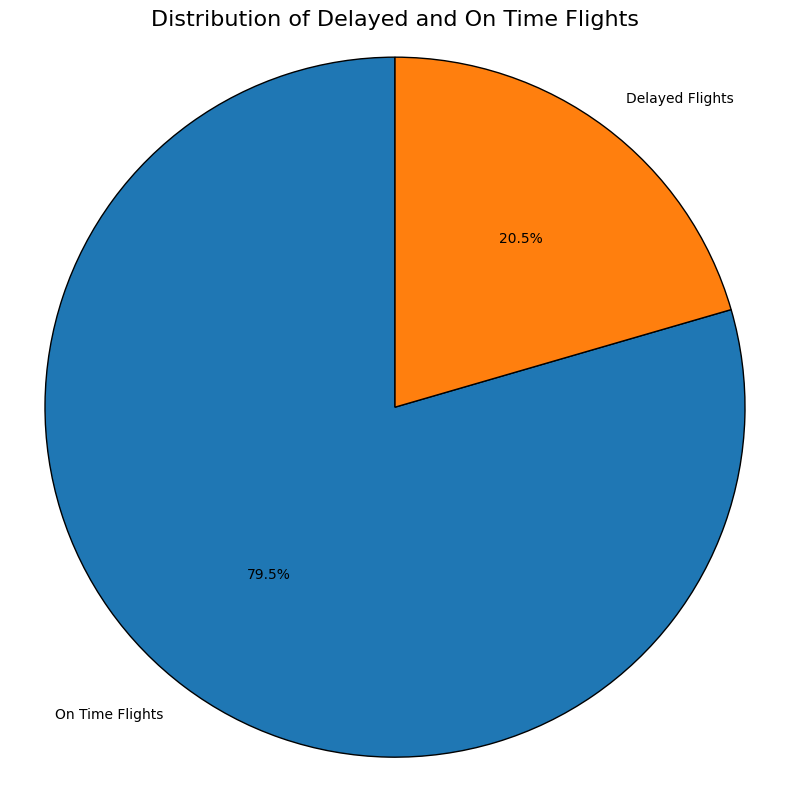

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 2. Calculate Frequencies ---
# Use value_counts() to count the occurrences of 0s and 1s.
counts = df['Delay'].value_counts()

# --- 3. Define Plotting Elements ---
sizes = counts.values

# Assign meaningful labels: 1 = Yes, 0 = No
custom_labels = []
for index_value in counts.index:
    if index_value == 1:
        custom_labels.append('Delayed Flights')
    elif index_value == 0:
        custom_labels.append('On Time Flights')
labels = custom_labels

# --- 4. Generate the Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',  # Show percentages with one decimal place
    startangle=90,      # Start the first slice at the top
    wedgeprops={'edgecolor': 'black'} # Add edge lines for clarity
)

# --- 5. Final Touches ---
plt.title('Distribution of Delayed and On Time Flights', fontsize=16)
plt.axis('equal') # Ensures the pie chart is a perfect circle
plt.tight_layout()


In [40]:
import pandas as pd

# 1. Snow airports list (airports with measurable snowfall)
snow_airports = [
    'FCA','SBN','CID','FNT','DSM','RAP','FWA','CHA','TYS',
    'ANC','LIT','AGS','CAK','SMF','ONT'
]

# 2. Filter to full dataset + snow airports only
snow_df = df[df['DEST'].isin(snow_airports)].copy()

# 3. Create half-month indicator
snow_df.loc[:, 'Half'] = snow_df['DAY_OF_MONTH'].apply(lambda x: 'H1' if x <= 15 else 'H2')

# 4. Map month numbers to names + build period label
month_names = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}
snow_df.loc[:, 'Period'] = snow_df['MONTH'].map(month_names) + '-' + snow_df['Half']

# 5. Compute delay rate for each half-month period
half_month_delay_snow = snow_df.groupby('Period')['Delay'].mean().reset_index()

# 6. Sort from highest delay rate to lowest
half_month_delay_snow = half_month_delay_snow.sort_values(by='Delay', ascending=False)

# 7. Print results
print("\n=== Delay Rates by Half-Month (Snow Airports Only — Full Dataset) ===")
print(half_month_delay_snow.to_string(index=False, float_format="%.4f"))



=== Delay Rates by Half-Month (Snow Airports Only — Full Dataset) ===
Period  Delay
Jan-H1 0.2871
Jun-H2 0.2655
Jul-H2 0.2636
Dec-H2 0.2573
Feb-H2 0.2558
Aug-H1 0.2463
Jul-H1 0.2256
Mar-H1 0.2248
Jun-H1 0.2244
Apr-H1 0.2201
May-H2 0.2151
Jan-H2 0.2104
Feb-H1 0.2092
May-H1 0.1986
Aug-H2 0.1980
Dec-H1 0.1899
Mar-H2 0.1853
Nov-H2 0.1816
Sep-H2 0.1815
Apr-H2 0.1798
Oct-H1 0.1661
Sep-H1 0.1616
Nov-H1 0.1561
Oct-H2 0.1541


Results

/tmp/ipython-input-2506420459.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


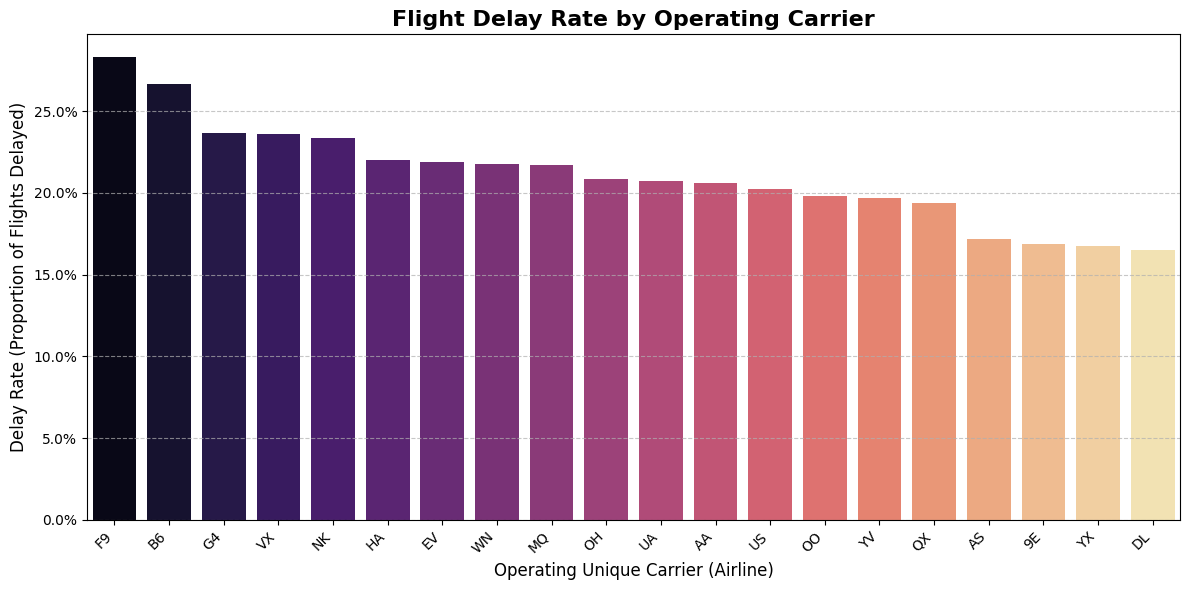


--- Carriers ranked by Delay Rate ---
Top 5 Carriers:
Carrier  Delay_Rate
     F9      0.2828
     B6      0.2664
     G4      0.2367
     VX      0.2358
     NK      0.2333

Bottom 5 Carriers:
Carrier  Delay_Rate
     QX      0.1936
     AS      0.1715
     9E      0.1689
     YX      0.1676
     DL      0.1652


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- ASSUMPTION: Your flight data is loaded into a DataFrame named 'df' ---
# Example: df = pd.read_csv('your_flight_data.csv')

# 1. Calculate the Delay Rate by Carrier
# Group by OP_UNIQUE_CARRIER and calculate the mean of the 'Delay' column.
# Since 1=Delayed and 0=On Time, the mean is the proportion of delayed flights (the delay rate).
carrier_delay_rate = df.groupby('OP_UNIQUE_CARRIER')['Delay'].mean().sort_values(ascending=False)

# Convert the result to a DataFrame for clear plotting
carrier_delay_df = carrier_delay_rate.reset_index()
carrier_delay_df.columns = ['Carrier', 'Delay_Rate']

# 2. Create the Visualization (Bar Chart)
plt.figure(figsize=(12, 6))

# Use seaborn for the bar plot
sns.barplot(
    x='Carrier',
    y='Delay_Rate',
    data=carrier_delay_df,
    palette='magma' # Changed palette for visual variety
)

# 3. Enhance the Plot
plt.title('Flight Delay Rate by Operating Carrier', fontsize=16, fontweight='bold')
plt.xlabel('Operating Unique Carrier (Airline)', fontsize=12)
plt.ylabel('Delay Rate (Proportion of Flights Delayed)', fontsize=12)

# Format the y-axis to show percentages (optional, but good for interpretation)
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.xticks(rotation=45, ha='right') # Rotate carrier names for better fit
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Optional: Print the top 5 and bottom 5 carriers by delay rate
print("\n--- Carriers ranked by Delay Rate ---")
print("Top 5 Carriers:")
print(carrier_delay_df.head().to_string(index=False, float_format="%.4f"))
print("\nBottom 5 Carriers:")
print(carrier_delay_df.tail().to_string(index=False, float_format="%.4f"))

/tmp/ipython-input-3837913822.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


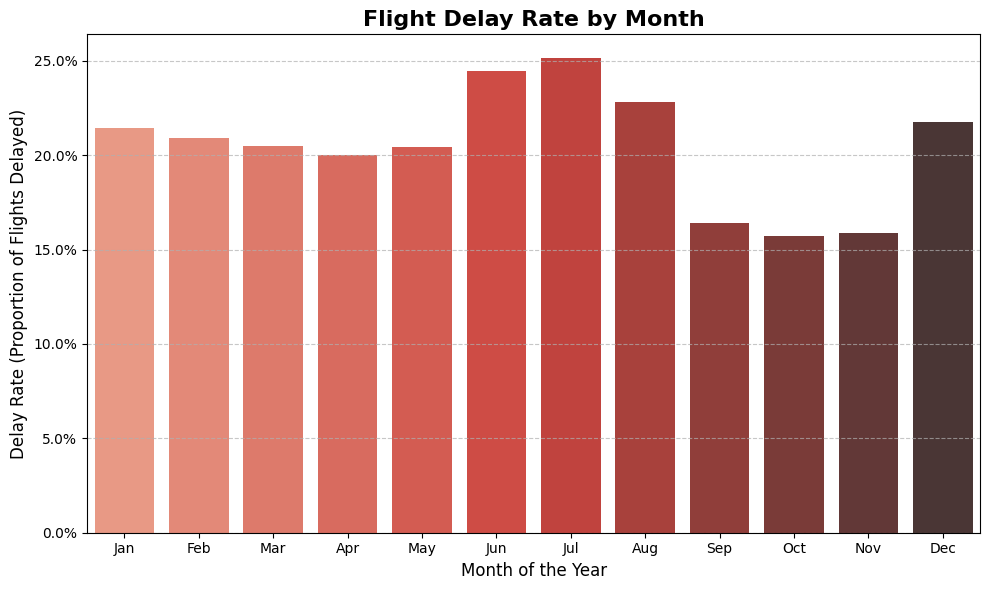


--- Delay Rates by Month ---
Month_Name  Delay_Rate
       Jan      0.2145
       Feb      0.2089
       Mar      0.2047
       Apr      0.2003
       May      0.2045
       Jun      0.2443
       Jul      0.2514
       Aug      0.2282
       Sep      0.1639
       Oct      0.1572
       Nov      0.1586
       Dec      0.2173


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- ASSUMPTION: Your flight data is loaded into a DataFrame named 'df' ---
# Target column is 'Delay' (1=Delayed, 0=On Time).

# 1. Calculate the Delay Rate by Month
# Group by 'MONTH' and calculate the mean of the 'Delay' column.
# Sort by MONTH (ascending) to maintain chronological order.
month_delay_rate = df.groupby('MONTH')['Delay'].mean().sort_index(ascending=True)

# Convert the result to a DataFrame for clear plotting
month_delay_df = month_delay_rate.reset_index()
month_delay_df.columns = ['Month', 'Delay_Rate']

# Optional: Map month numbers to names for better readability on the plot
# This requires a standard mapping, which we can create here:
month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
month_delay_df['Month_Name'] = month_delay_df['Month'].map(month_names)


# 2. Create the Visualization (Bar Chart)
plt.figure(figsize=(10, 6))

# Use Month_Name for the x-axis to make the plot easier to read
sns.barplot(
    x='Month_Name',
    y='Delay_Rate',
    data=month_delay_df,
    palette='Reds_d' # Use a different palette
)

# 3. Enhance the Plot
plt.title('Flight Delay Rate by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month of the Year', fontsize=12)
plt.ylabel('Delay Rate (Proportion of Flights Delayed)', fontsize=12)

# Format the y-axis to show percentages
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('delay_rate_by_month.png') # Save the figure
plt.show()

# Print the calculated rates
print("\n--- Delay Rates by Month ---")
print(month_delay_df[['Month_Name', 'Delay_Rate']].to_string(index=False, float_format="%.4f"))

/tmp/ipython-input-2176545106.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Flight Delay Rate for Specific Airports:
ORIGIN  Delay_Rate
   EWR      0.2334
   JFK      0.2191
   PHL      0.2050
   SCE      0.1776
   PIT      0.1598


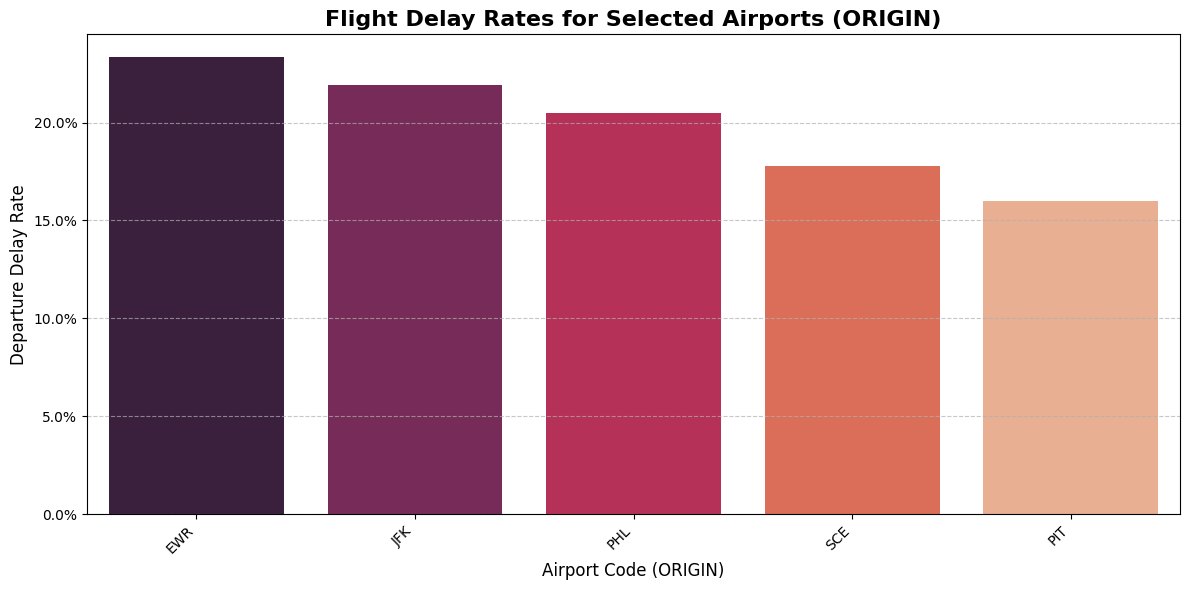

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# --- Configuration ---
AIRPORT_COLUMN = 'ORIGIN'
# NEW: Define the list of airports you want to include
SPECIFIC_AIRPORTS = ['EWR', 'JFK', 'SCE', 'PHL', 'PIT']

# 1. Calculate the Delay Rate
# Group by AIRPORT_COLUMN and calculate the mean of the 'Delay' column.
# NOTE: Assuming 'df' (the DataFrame) is available in the current environment
origin_delay_rate = df.groupby(AIRPORT_COLUMN)['Delay'].mean()

# 2. Get the Specific Airports by Delay Rate
# Filter the calculated rates by the list of specific airports
specific_delay_rate = origin_delay_rate.loc[SPECIFIC_AIRPORTS]

# Convert the Series to a DataFrame, sort (optional, but good for charts), and rename columns
specific_delay_rate_df = specific_delay_rate.sort_values(ascending=False).reset_index()
specific_delay_rate_df.columns = [AIRPORT_COLUMN, 'Delay_Rate']

# 3. Create the Visualization (Bar Chart)
plt.figure(figsize=(12, 6))

sns.barplot(
    x=AIRPORT_COLUMN,
    y='Delay_Rate',
    data=specific_delay_rate_df,
    palette='rocket' # Color palette for origin
)

# 4. Enhance the Plot
plt.title(f'Flight Delay Rates for Selected Airports ({AIRPORT_COLUMN})', fontsize=16, fontweight='bold')
plt.xlabel(f'Airport Code ({AIRPORT_COLUMN})', fontsize=12)
plt.ylabel('Departure Delay Rate', fontsize=12)

# Format the y-axis to show percentages
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Update the file name to reflect the specific list
plt.savefig(f'delay_rate_by_{AIRPORT_COLUMN.lower()}_specific_airports.png')
# plt.show() # Removed as per interpreter guidelines

print(f"Flight Delay Rate for Specific Airports:")
print(specific_delay_rate_df.to_string(index=False, float_format="%.4f"))

In [47]:
import numpy as np
import pandas as pd

# Assume df is your DataFrame with 'MONTH' and 'DAY_OF_MONTH' columns
conditions = [
    # All of December (1 to 31)
    (df['MONTH'] == 12),
    # January 1 to 10
    (df['MONTH'] == 1) & (df['DAY_OF_MONTH'] <= 10)
]

# Set the values for the cases where conditions are TRUE
choices = ['YES', 'YES']

# Apply the logic
df['WINTER_HOLIDAY'] = np.select(conditions, choices, default='NO')
print(df)

          YEAR  MONTH  DAY_OF_MONTH  DAY_OF_WEEK                FL_DATE  \
0         2015      4             1            3   4/1/2015 12:00:00 AM   
1         2015      4             1            3   4/1/2015 12:00:00 AM   
2         2015      4             1            3   4/1/2015 12:00:00 AM   
3         2015      4             1            3   4/1/2015 12:00:00 AM   
4         2015      4             1            3   4/1/2015 12:00:00 AM   
...        ...    ...           ...          ...                    ...   
14593784  2024      9            30            1  9/30/2024 12:00:00 AM   
14593785  2024      9            30            1  9/30/2024 12:00:00 AM   
14593786  2024      9            30            1  9/30/2024 12:00:00 AM   
14593787  2024      9            30            1  9/30/2024 12:00:00 AM   
14593788  2024      9            30            1  9/30/2024 12:00:00 AM   

         OP_UNIQUE_CARRIER  OP_CARRIER_AIRLINE_ID  ORIGIN_AIRPORT_ID ORIGIN  \
0                   


--- Generating plot for: WINTER_HOLIDAY vs. Delay Rate (Proportion) ---


/tmp/ipython-input-2683420581.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


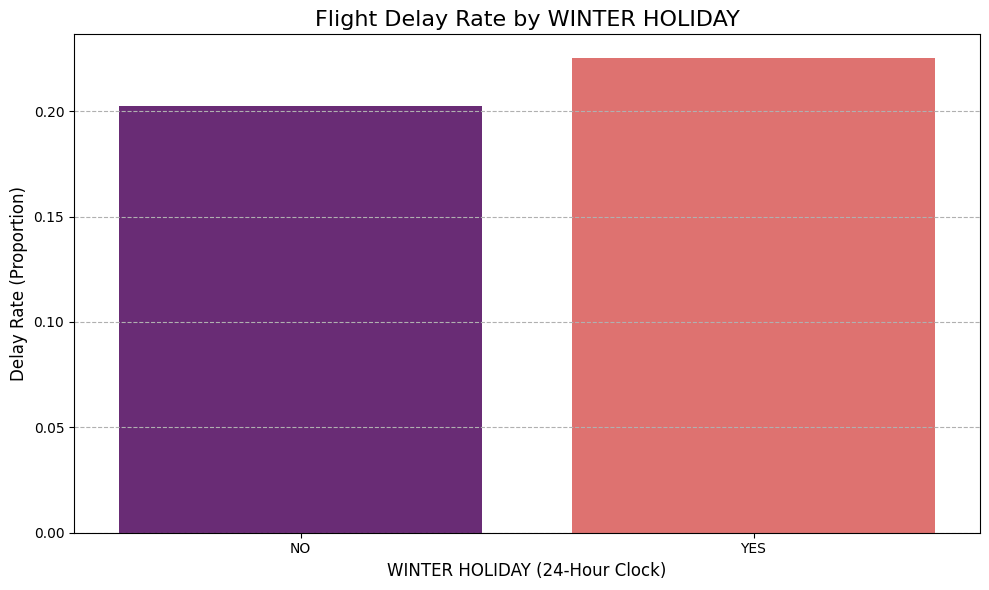

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Preparation ---

# Define variables for execution
VARIABLES_TO_PLOT = ['WINTER_HOLIDAY']
DELAY_COLUMN = 'Delay'

# --- 2. Plotting Function Definition ---

def plot_delay_rate(df, category_col, delay_col):
    """Calculates and plots the delay rate as a proportion (decimal) for a given hourly column."""

    # Calculation: The .mean() of the binary delay_col automatically gives the proportion (decimal rate).
    delay_rate = df.groupby(category_col)[delay_col].mean().reset_index()
    delay_rate.rename(columns={delay_col: 'Delay_Rate_Proportion'}, inplace=True)

    # Sort by hour
    delay_rate = delay_rate.sort_values(by=category_col)

    # Create the plot using seaborn (bar chart)
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=category_col,
        y='Delay_Rate_Proportion', # Using the decimal proportion for Y-axis
        data=delay_rate,
        palette='magma'
    )
    plt.title(f'Flight Delay Rate by {category_col.replace("_", " ")}', fontsize=16)
    plt.xlabel(f'{category_col.replace("_", " ")} (24-Hour Clock)', fontsize=12)
    plt.ylabel('Delay Rate (Proportion)', fontsize=12) # Updated Y-axis label
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.savefig(f'{category_col}_delay_rate_proportion.png')
    plt.show()

# --- 3. Execution ---

# Loop through the three variables and generate a bar chart for each.
for col in VARIABLES_TO_PLOT:
    print(f"\n--- Generating plot for: {col} vs. {DELAY_COLUMN} Rate (Proportion) ---")
    plot_delay_rate(df, col, DELAY_COLUMN)

After Modeling

In [53]:
import pandas as pd

data = [
    ['Accuracy', 0.65, 0.80],
    ['F-1 Score', 0.69, 0.71],
    ['Precision', 0.76, 0.64],
    ['Recall', 0.65, 0.80]
]

columns = [' ', 'XGBoost', 'Random Forest']

table1 = pd.DataFrame(data, columns=columns)
print(table1)

              XGBoost  Random Forest
0   Accuracy     0.65           0.80
1  F-1 Score     0.69           0.71
2  Precision     0.76           0.64
3     Recall     0.65           0.80
